# Discharge reconstruction during data gaps 2022-2023

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
upper_sulphur = pd.read_csv("upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
redondo = pd.read_csv("redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
jemez = pd.read_csv("jemez/jemez_stream_gauge.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft
redondo = pd.read_csv("redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
precipitation = pd.read_csv('redondo_airtemp_pcp.csv', parse_dates=[0], index_col=0, na_values=['NaN']) 

# precip data cleanup
precipitation.index = pd.to_datetime(precipitation.index, format='%m/%d/%Y', errors='coerce')
precipitation = precipitation[precipitation.index.notna()]  # remove rows with invalid dates
precipitation = precipitation.replace(-9999, np.nan) # replace -9999 with NaN 

# convert ft^3/s to m3/s for san_antonio, lower_sulphur, and upper_sulphur
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168
jemez["jemez (ft)"] = jemez["value"] # keep jemez in ft for now

# la jara data as base 
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)

# remove timezone info from all indices to enable joining
lajara_2022.index = lajara_2022.index.tz_localize(None) if lajara_2022.index.tz is not None else lajara_2022.index
lajara_2023.index = lajara_2023.index.tz_localize(None) if lajara_2023.index.tz is not None else lajara_2023.index
redondo.index = redondo.index.tz_localize(None) if redondo.index.tz is not None else redondo.index
san_antonio.index = san_antonio.index.tz_localize(None) if san_antonio.index.tz is not None else san_antonio.index
lower_sulphur.index = lower_sulphur.index.tz_localize(None) if lower_sulphur.index.tz is not None else lower_sulphur.index
upper_sulphur.index = upper_sulphur.index.tz_localize(None) if upper_sulphur.index.tz is not None else upper_sulphur.index
jemez.index = jemez.index.tz_localize(None) if jemez.index.tz is not None else jemez.index

Only keep data from 2022 and 2023 

In [3]:
# only keep data from 2022 and 2023
san_antonio = san_antonio[(san_antonio.index.year >= 2022) & (san_antonio.index.year <= 2023)]
redondo = redondo[(redondo.index.year >= 2022) & (redondo.index.year <= 2023)]
lower_sulphur = lower_sulphur[(lower_sulphur.index.year >= 2022) & (lower_sulphur.index.year <= 2023)]
upper_sulphur = upper_sulphur[(upper_sulphur.index.year >= 2022) & (upper_sulphur.index.year <= 2023)]
precipitation = precipitation[(precipitation.index.year >= 2022) & (precipitation.index.year <= 2023)]


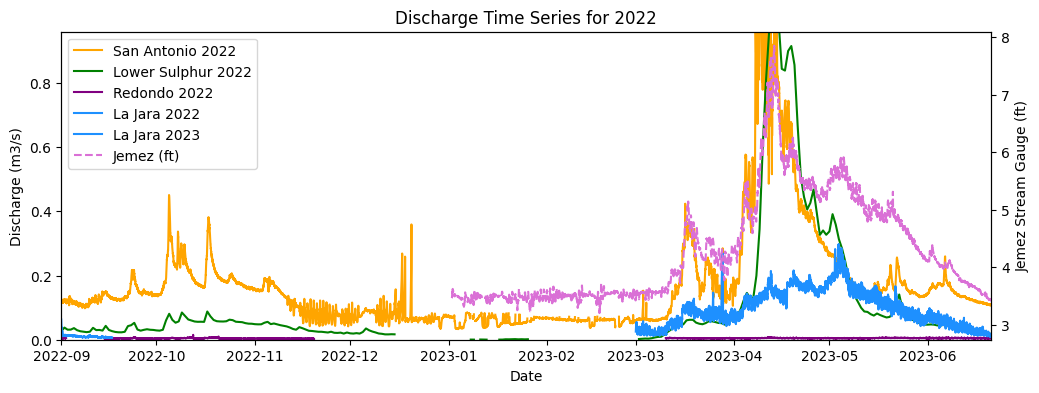

In [4]:
# plot discharge time series for all 4 sites
# 2022
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(san_antonio.index, san_antonio['san_antonio (m3/s)'], label='San Antonio 2022', color='orange')
ax.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], label='Lower Sulphur 2022', color='green')
#ax.plot(upper_sulphur.index, upper_sulphur['upper_sulphur (m3/s)'], label='Upper Sulphur 2022', color='firebrick')
ax.plot(redondo.index, redondo['redondo (m3/s)'], label='Redondo 2022', color='purple')
ax.plot(lajara_2022.index, lajara_2022['la_jara'], label='La Jara 2022', color='dodgerblue')
ax.plot(lajara_2023.index, lajara_2023['la_jara'], label='La Jara 2023', color= 'dodgerblue')
ax.set_ylabel('Discharge (m3/s)')


ax2 = ax.twinx()
ax2.plot(jemez.index, jemez['jemez (ft)'], label='Jemez (ft)', color='orchid', linestyle='--')
ax2.set_ylabel('Jemez Stream Gauge (ft)')  

# combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_ylim(0, 0.96)
ax.set_title('Discharge Time Series for 2022')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-09-01'), pd.Timestamp('2023-06-21'))
plt.show()

### Using Redondo: 09/17/22 - 11/19/22

In [5]:
lajara_redondo = lajara_2022.join(redondo['redondo (m3/s)'], how='outer')
gap_start = pd.Timestamp('2022-09-17')
gap_end = pd.Timestamp('2022-11-19')
gap_mask = (lajara_redondo.index >= gap_start) & (lajara_redondo.index <= gap_end)

# calculate discharge using rating curve
#lajara_redondo['estimated_Q'] = 0.0059 * np.log(0.0397 * lajara_redondo['redondo (m3/s)']) # logarithmic
#lajara_redondo['estimated_Q'] = 15.697062 * lajara_redondo['redondo (m3/s)'] + -0.033070 # linear
#lajara_redondo['estimated_Q'] = 1.227140 * lajara_redondo['redondo (m3/s)'] + 0.001567 # linear, excluding 2023
lajara_redondo['estimated_Q'] = 1.124772 * lajara_redondo['redondo (m3/s)'] + 0.001617 # linear, excluding 2023 and storms
#lajara_redondo['estimated_Q'] = 0.000006 * np.exp(2091.644682 * lajara_redondo['redondo (m3/s)']) # exponential

# fill missing discharge values in lajara_2022 with estimated values from rating curve
lajara_redondo.loc[gap_mask & lajara_redondo['la_jara'].isna(), 'la_jara'] = lajara_redondo.loc[gap_mask & lajara_redondo['la_jara'].isna(), 'estimated_Q']

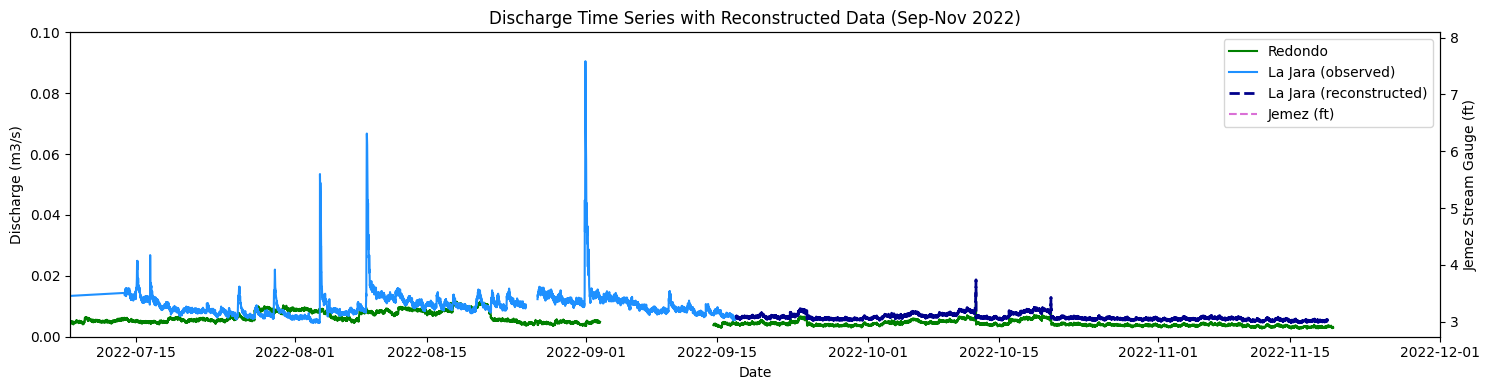

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))

# plot redondo
ax.plot(redondo.index, redondo['redondo (m3/s)'], 
        label='Redondo', color='green')

# plot original La Jara data (both years)
ax.plot(lajara_2022.index, lajara_2022['la_jara'], 
        label='La Jara (observed)', color='dodgerblue')
ax.plot(lajara_2023.index, lajara_2023['la_jara'], 
        color='dodgerblue')

# plot reconstructed discharge during gap period
reconstructed = lajara_redondo.loc[gap_mask]
ax.plot(reconstructed.index, reconstructed['la_jara'], 
        label='La Jara (reconstructed)', color='darkblue', linestyle='--', linewidth=2)

ax.set_ylabel('Discharge (m3/s)')

# add Jemez on second y-axis
ax2 = ax.twinx()
ax2.plot(jemez.index, jemez['jemez (ft)'], 
         label='Jemez (ft)', color='orchid', linestyle='--')
ax2.set_ylabel('Jemez Stream Gauge (ft)')  

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_title('Discharge Time Series with Reconstructed Data (Sep-Nov 2022)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2022-12-01'))
ax.set_ylim(0, 0.1)
plt.tight_layout()
plt.show()

#### Applying precipitation increases

In [7]:
# merge reconstructed data with precipitation
reconstructed_with_precip = lajara_redondo[['la_jara', 'estimated_Q']].copy()

# multiplier from precipitation analysis
multiplier = 0.0502  # (m³/s per mm)
baseflow_intercept = -0.0055  #  (m³/s)

# add date column to match daily precipitation to all timestamps in that day
reconstructed_with_precip['date_only'] = reconstructed_with_precip.index.date
# create a daily precipitation dataframe with just dates (no time component)
precip_daily = precipitation['total_precip'].copy()
precip_daily.index = precip_daily.index.date
# join daily precipitation to discharge data
reconstructed_with_precip = reconstructed_with_precip.join(precip_daily, on='date_only', how='left')

# apply precipitation adjustment only for reconstructed values during gap period
# and only for days when precipitation > 0.2 mm
reconstructed_with_precip['la_jara_adjusted'] = reconstructed_with_precip['la_jara'].copy()

# identify dates (not timestamps) with precipitation > 0.5 mm
precip_mask = (reconstructed_with_precip['total_precip'] > 0.5) & gap_mask
flow_increase = reconstructed_with_precip.loc[precip_mask, 'total_precip'] * multiplier
reconstructed_with_precip.loc[precip_mask, 'la_jara_adjusted'] = reconstructed_with_precip.loc[precip_mask, 'la_jara'] + flow_increase

# count unique dates with precipitation > 0.2 mm during gap
unique_precip_days = reconstructed_with_precip[precip_mask & reconstructed_with_precip['total_precip'].notna()]['date_only'].nunique()
unique_gap_days = reconstructed_with_precip[gap_mask]['date_only'].nunique()

# Display summary
print(f"Multiplier: {multiplier:.6f} m³/s per mm precipitation")
print(f"Baseflow intercept: {baseflow_intercept:.6f} m³/s")
print(f"\nDays with precipitation > 0.5 mm during gap: {unique_precip_days}")


Multiplier: 0.050200 m³/s per mm precipitation
Baseflow intercept: -0.005500 m³/s

Days with precipitation > 0.5 mm during gap: 4


In [8]:
# assume hydrograph-style response (smooth distribution over time)
from scipy import signal

# create a copy for hydrograph approach
reconstructed_hydro = lajara_redondo[['la_jara', 'estimated_Q']].copy()
reconstructed_hydro['date_only'] = reconstructed_hydro.index.date
reconstructed_hydro = reconstructed_hydro.join(precip_daily, on='date_only', how='left')
# initialize adjusted discharge
reconstructed_hydro['la_jara_hydro'] = reconstructed_hydro['la_jara'].copy()

# hydrograph parameters
peak_hour = 15  # assume time of peak
time_to_peak_hours = 2  # hours from start of precip to peak discharge
recession_hours = 6  # hours for recession limb

# create a unit hydrograph response function (gamma distribution shape)
def create_unit_hydrograph(time_to_peak, recession_time, dt=1):
    """
    Create a unit hydrograph using gamma distribution
    dt: time step in hours (match your discharge data resolution)
    """
    total_duration = time_to_peak + recession_time
    t = np.arange(0, total_duration, dt)
    # gamma distribution parameters
    shape = 2.5  # Controls skewness
    scale = time_to_peak / shape
    # gamma PDF
    from scipy.stats import gamma
    response = gamma.pdf(t, shape, scale=scale)
    
    # OPTION 1: Normalize by MAX (peak = 1.0) instead of by SUM
    # This makes the peak discharge match the square-wave magnitude
    response = response / np.max(response)
    
    return response

# find time resolution of discharge data
time_diff = reconstructed_hydro.index.to_series().diff().mode()[0]
dt_hours = time_diff.total_seconds() / 3600  # convert to hours
# create unit hydrograph
unit_hydrograph = create_unit_hydrograph(time_to_peak_hours, recession_hours, dt=dt_hours)

print(f"Discharge data time resolution: {dt_hours:.2f} hours")
print(f"Unit hydrograph length: {len(unit_hydrograph)} time steps ({len(unit_hydrograph)*dt_hours:.1f} hours)")
print(f"Unit hydrograph max weight: {unit_hydrograph.max():.6f}")
print(f"Unit hydrograph sum of weights: {unit_hydrograph.sum():.6f}")

# apply hydrograph response to each precipitation event
# for each day with precip > 0.62 mm, apply the unit hydrograph
precip_days = reconstructed_hydro[
    gap_mask & (reconstructed_hydro['total_precip'] > 0.62)
]['date_only'].unique()

print(f"\nApplying hydrograph response to {len(precip_days)} precipitation events...")

for precip_date in precip_days:
    # Find the precipitation amount
    precip_amount = reconstructed_hydro[
        reconstructed_hydro['date_only'] == precip_date
    ]['total_precip'].iloc[0]
    
    # Calculate total flow increase
    total_flow_increase = precip_amount * multiplier
    
    print(f"  {precip_date}: {precip_amount:.2f} mm precip → {total_flow_increase:.6f} m³/s total increase")
    
    # Find the peak time (assume noon of that day)
    peak_time = pd.Timestamp(precip_date) + pd.Timedelta(hours=peak_hour)
    
    # Find the index closest to peak time (handle duplicate timestamps)
    time_diff = abs(reconstructed_hydro.index - peak_time)
    peak_idx = time_diff.argmin()
    
    # Apply unit hydrograph starting from peak time
    applied_count = 0
    for i, weight in enumerate(unit_hydrograph):
        idx = peak_idx + i
        if idx < len(reconstructed_hydro) and gap_mask[idx]:
            flow_contribution = total_flow_increase * weight
            reconstructed_hydro.iloc[idx, reconstructed_hydro.columns.get_loc('la_jara_hydro')] += flow_contribution
            applied_count += 1
    
    print(f"    → Applied to {applied_count} timestamps (max contrib: {(total_flow_increase * unit_hydrograph.max()):.6f} m³/s)")

Discharge data time resolution: 0.25 hours
Unit hydrograph length: 32 time steps (8.0 hours)
Unit hydrograph max weight: 1.000000
Unit hydrograph sum of weights: 10.363887

Applying hydrograph response to 3 precipitation events...
  2022-09-22: 0.64 mm precip → 0.032128 m³/s total increase
    → Applied to 32 timestamps (max contrib: 0.032128 m³/s)
  2022-10-03: 0.78 mm precip → 0.039156 m³/s total increase
    → Applied to 32 timestamps (max contrib: 0.039156 m³/s)
  2022-10-16: 1.05 mm precip → 0.052710 m³/s total increase
    → Applied to 32 timestamps (max contrib: 0.052710 m³/s)


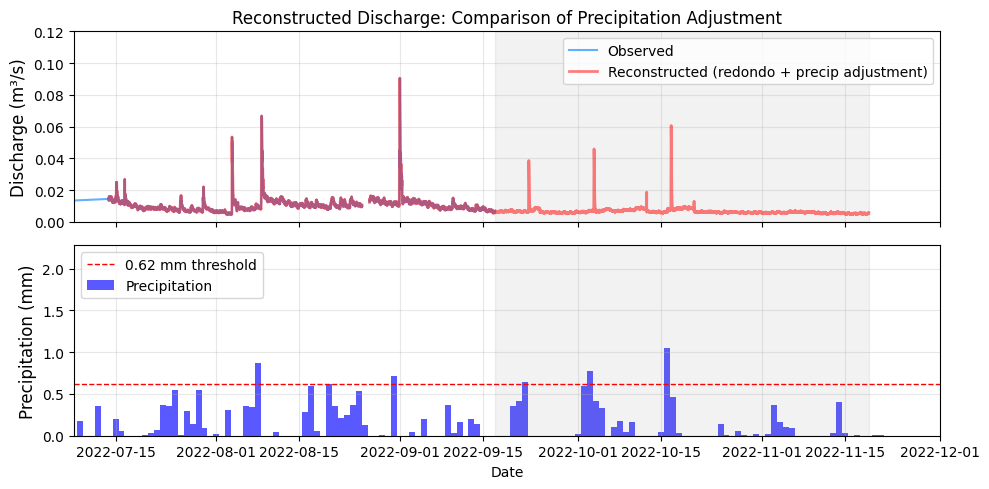

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# original vs reconstructed discharge
ax1.plot(lajara_2022.index, lajara_2022['la_jara'], label='Observed', color='dodgerblue', alpha=0.7, linewidth=1.5)
ax1.plot(reconstructed_hydro.index, reconstructed_hydro['la_jara_hydro'], label='Reconstructed (redondo + precip adjustment)', color='red', linestyle='-', linewidth=2, alpha=0.5)
ax1.set_ylabel('Discharge (m³/s)', fontsize=12)
ax1.set_title('Reconstructed Discharge: Comparison of Precipitation Adjustment', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 0.12)

#  precipitation
ax2.bar(precipitation.index, precipitation['total_precip'], 
        alpha=0.65, color='blue', width=1, label='Precipitation')
ax2.axhline(y=0.62, color='red', linestyle='--', linewidth=1, label='0.62 mm threshold')
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

for ax in [ax1, ax2]:
    ax.axvspan(gap_start, gap_end, alpha=0.1, color='gray')

ax1.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2022-12-01'))
ax2.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2022-12-01'))

plt.tight_layout()
plt.show()

### Using Lower Sulphur: 09/17/22 - 12/15/22

In [10]:
lajara_sulphur = lajara_2022.join(lower_sulphur['lower_sulphur (m3/s)'], how='outer')
# filter Lower Sulphur data for the gap period
gap_start = pd.Timestamp('2022-09-17')
gap_end = pd.Timestamp('2022-12-15')
gap_mask = (lajara_sulphur.index >= gap_start) & (lajara_sulphur.index <= gap_end)

# calculate discharge using rating curve

#lajara_sulphur['estimated_Q'] = 0.1191 * lajara_sulphur['lower_sulphur (m3/s)']**0.4735 - 0.015 # power law
#lajara_sulphur['estimated_Q'] = 0.0406 * np.log(0.1871 * lajara_sulphur['lower_sulphur (m3/s)']) # logarithmic
lajara_sulphur['estimated_Q'] = 0.196640 * lajara_sulphur['lower_sulphur (m3/s)'] + 0.002785 # linear
#lajara_sulphur['estimated_Q'] = 0.003654 * np.exp(57.224281 * lajara_sulphur['lower_sulphur (m3/s)']) # exponential

# fill missing discharge values in lajara_2022 with estimated values from rating curve
lajara_sulphur.loc[gap_mask & lajara_sulphur['la_jara'].isna(), 'la_jara'] = lajara_sulphur.loc[gap_mask & lajara_sulphur['la_jara'].isna(), 'estimated_Q']

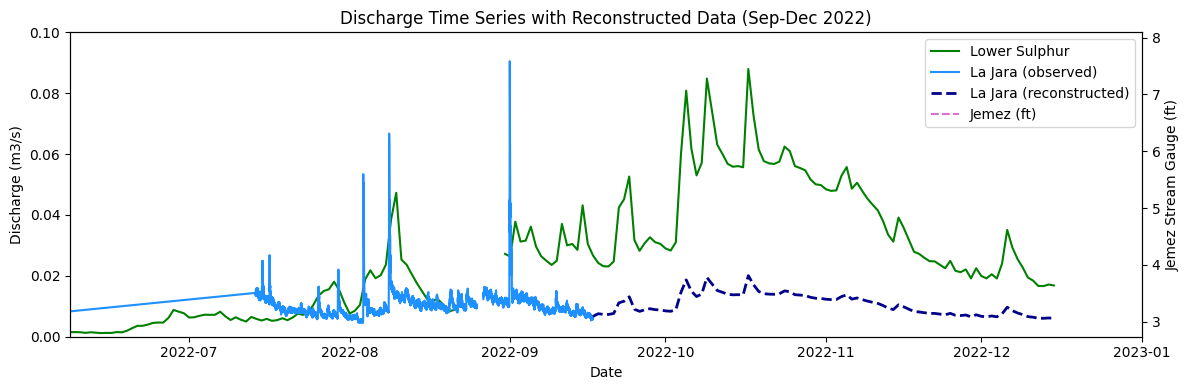

In [11]:
# Plot discharge with reconstructed data highlighted
fig, ax = plt.subplots(figsize=(12, 4))

# Plot Lower Sulphur
ax.plot(lower_sulphur.index, lower_sulphur['lower_sulphur (m3/s)'], 
        label='Lower Sulphur', color='green')

# Plot original La Jara data (both years)
ax.plot(lajara_2022.index, lajara_2022['la_jara'], 
        label='La Jara (observed)', color='dodgerblue')
ax.plot(lajara_2023.index, lajara_2023['la_jara'], 
        color='dodgerblue')

# Plot reconstructed discharge during gap period
reconstructed = lajara_sulphur.loc[gap_mask]
ax.plot(reconstructed.index, reconstructed['la_jara'], 
        label='La Jara (reconstructed)', color='darkblue', linestyle='--', linewidth=2)

ax.set_ylabel('Discharge (m3/s)')

# Add Jemez on second y-axis
ax2 = ax.twinx()
ax2.plot(jemez.index, jemez['jemez (ft)'], 
         label='Jemez (ft)', color='orchid', linestyle='--')
ax2.set_ylabel('Jemez Stream Gauge (ft)')  

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_title('Discharge Time Series with Reconstructed Data (Sep-Dec 2022)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-06-08'), pd.Timestamp('2023-01-01'))
ax.set_ylim(0, 0.1)
plt.tight_layout()
plt.show()

### Using Jemez: 01/01/23 - 03/01/23

In [12]:
lajara_jemez = lajara_2023.join(jemez['jemez (ft)'], how='outer')
gap_start = pd.Timestamp('2023-01-01')
gap_end = pd.Timestamp('2023-03-01')
gap_mask = (lajara_jemez.index >= gap_start) & (lajara_jemez.index <= gap_end)

# calculate discharge using rating curve
#lajara_jemez['estimated_Q'] = 0.028849 * lajara_jemez['jemez (ft)'] + -0.084321 # linear
lajara_jemez['estimated_Q'] = 0.000001 * np.exp(2.850722 * lajara_jemez['jemez (ft)']) # exponential

# fill missing discharge values in lajara_2022 with estimated values from rating curve
lajara_jemez.loc[gap_mask & lajara_jemez['la_jara'].isna(), 'la_jara'] = lajara_jemez.loc[gap_mask & lajara_jemez['la_jara'].isna(), 'estimated_Q']

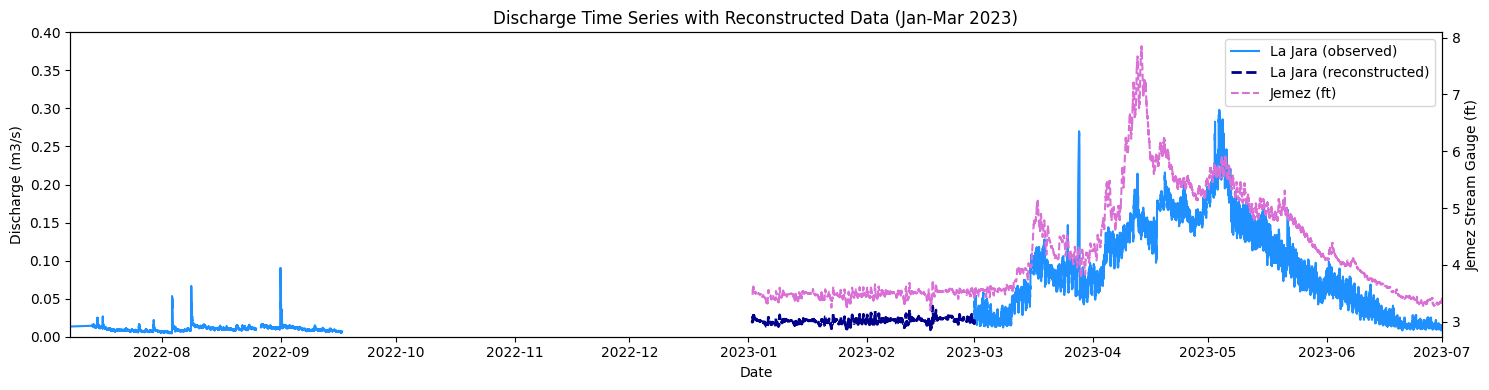

In [13]:
fig, ax = plt.subplots(figsize=(15, 4))

# plot original La Jara data (both years)
ax.plot(lajara_2022.index, lajara_2022['la_jara'], 
        label='La Jara (observed)', color='dodgerblue')
ax.plot(lajara_2023.index, lajara_2023['la_jara'], 
        color='dodgerblue')

# plot reconstructed discharge during gap period
reconstructed = lajara_jemez.loc[gap_mask]
ax.plot(reconstructed.index, reconstructed['la_jara'], 
        label='La Jara (reconstructed)', color='darkblue', linestyle='--', linewidth=2)

ax.set_ylabel('Discharge (m3/s)')

# add Jemez on second y-axis
ax2 = ax.twinx()
ax2.plot(jemez.index, jemez['jemez (ft)'], 
         label='Jemez (ft)', color='orchid', linestyle='--')
ax2.set_ylabel('Jemez Stream Gauge (ft)')  

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax.set_title('Discharge Time Series with Reconstructed Data (Jan-Mar 2023)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2023-07-01'))
ax.set_ylim(0, 0.4)
plt.tight_layout()
plt.show()

## Combine re-structured hydrographs


In [14]:
obs_2022 = lajara_2022['la_jara'].groupby(level=0).mean()
obs_2023 = lajara_2023['la_jara'].groupby(level=0).mean()
observed_la_jara = pd.concat([obs_2022, obs_2023]).groupby(level=0).mean()

# Use Redondo + precipitation-adjusted hydrograph reconstruction
redondo_precip_recon = reconstructed_hydro['la_jara_hydro'].groupby(level=0).mean()
jemez_recon = lajara_jemez['la_jara'].groupby(level=0).mean()

full_index = observed_la_jara.index.union(redondo_precip_recon.index).union(jemez_recon.index).sort_values()

lajara_full = pd.DataFrame(index=full_index)
lajara_full['la_jara_observed'] = observed_la_jara
lajara_full['la_jara_redondo_precip'] = redondo_precip_recon
lajara_full['la_jara_jemez'] = jemez_recon

lajara_full['la_jara_full'] = (
    lajara_full['la_jara_observed']
    .combine_first(lajara_full['la_jara_redondo_precip'])
    .combine_first(lajara_full['la_jara_jemez'])
)

lajara_full

,la_jara_observed,la_jara_redondo_precip,la_jara_jemez,la_jara_full
2022-03-01 00:00:00,0.000806,0.000806,NaN,0.000806
2022-03-01 00:15:00,0.000797,0.000797,NaN,0.000797
2022-03-01 00:30:00,0.000788,0.000788,NaN,0.000788
2022-03-01 00:45:00,0.000780,0.000780,NaN,0.000780
2022-03-01 01:00:00,0.000772,0.000772,NaN,0.000772
...,...,...,...,...
2023-09-21 04:45:00,NaN,NaN,NaN,NaN
2023-09-21 05:00:00,NaN,NaN,NaN,NaN
2023-09-21 05:15:00,NaN,NaN,NaN,NaN
2023-09-21 05:30:00,NaN,NaN,NaN,NaN


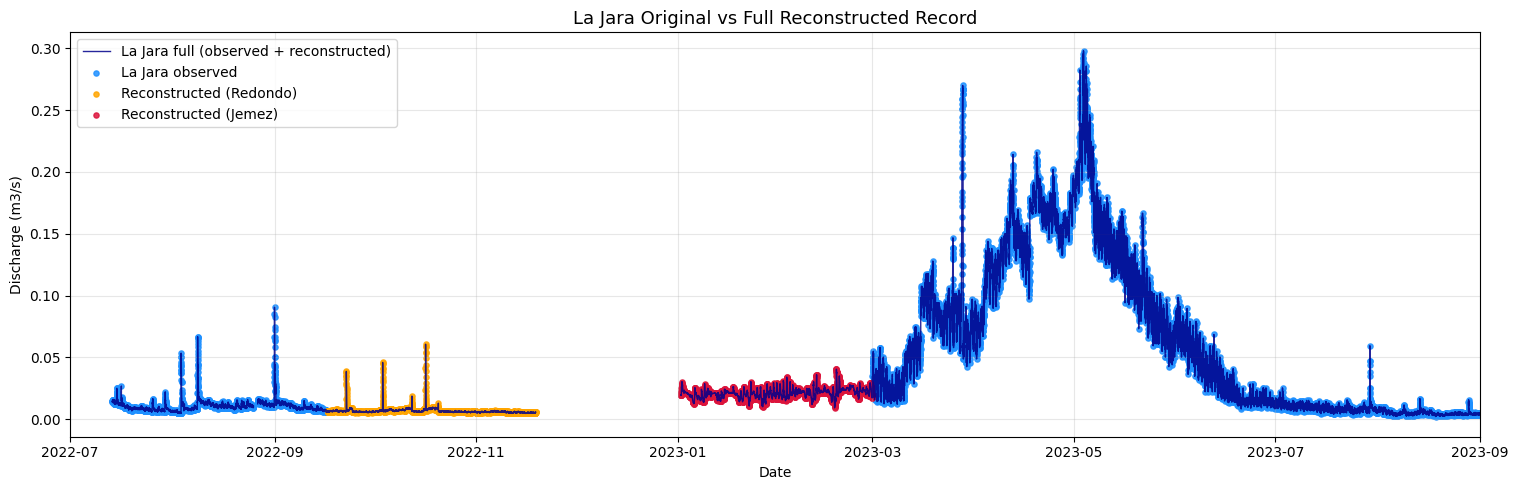

In [15]:
fig, ax = plt.subplots(figsize=(15, 5))

# full record after filling gaps
ax.plot(lajara_full.index, lajara_full['la_jara_full'], color='darkblue', linewidth=1, alpha=0.85, label='La Jara full (observed + reconstructed)')
# original observed data only
ax.scatter(lajara_full.index, lajara_full['la_jara_observed'], color='dodgerblue', s=14, alpha=0.85, label='La Jara observed')

# highlight reconstructed points by source
redondo_fill_mask = (lajara_full['la_jara_observed'].isna() & lajara_full['la_jara_redondo_precip'].notna() & lajara_full['la_jara_full'].notna())
jemez_fill_mask = (lajara_full['la_jara_observed'].isna() & lajara_full['la_jara_redondo_precip'].isna() & lajara_full['la_jara_jemez'].notna() & lajara_full['la_jara_full'].notna())

ax.scatter(lajara_full.index[redondo_fill_mask], lajara_full.loc[redondo_fill_mask, 'la_jara_full'], s=14, color='orange', alpha=0.85, label='Reconstructed (Redondo)')
ax.scatter(lajara_full.index[jemez_fill_mask], lajara_full.loc[jemez_fill_mask, 'la_jara_full'], s=14, color='crimson', alpha=0.85, label='Reconstructed (Jemez)')

ax.set_title('La Jara Original vs Full Reconstructed Record', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.xlim(pd.Timestamp('2022-07-01'), pd.Timestamp('2023-09-01'))
plt.show()


## Using San Antonio - Full Data Gap

In [16]:
lajara_full = pd.concat([lajara_2022, lajara_2023]).sort_index()
lajara_sanantonio = lajara_full.join(san_antonio['san_antonio (m3/s)'], how='outer')
gap_start = pd.Timestamp('2022-09-17')
gap_end = pd.Timestamp('2023-03-01')
gap_mask = (lajara_sanantonio.index >= gap_start) & (lajara_sanantonio.index <= gap_end)

# calculate discharge using rating curve
lajara_sanantonio['estimated_Q'] = 0.099720 * lajara_sanantonio['san_antonio (m3/s)'] + -0.005217 # linear, excluding 2023 and storms
#lajara_sanantonio['estimated_Q'] = 0.000006 * np.exp(2091.644682 * lajara_sanantonio['san_antonio (m3/s)']) # exponential

lajara_sanantonio.loc[gap_mask & lajara_sanantonio['la_jara'].isna(), 'la_jara'] = lajara_sanantonio.loc[gap_mask & lajara_sanantonio['la_jara'].isna(), 'estimated_Q']

In [17]:
# diagnose the discontinuity
gap_end_date = pd.Timestamp('2023-03-01')
taper_days =120  # apply correction over last 14 days (shorter = more drastic)
correction_multiplier = 3  # multiply discontinuity by this factor (>1.0 = goes higher)

# find first observed value after gap
first_obs_after_gap = lajara_sanantonio[
    (lajara_sanantonio.index >= gap_end_date) & 
    (lajara_sanantonio['la_jara'].notna()) & 
    (lajara_sanantonio['estimated_Q'].isna())
]['la_jara'].first_valid_index()

if first_obs_after_gap is not None:
    first_obs_value = lajara_sanantonio.loc[first_obs_after_gap, 'la_jara']
    
    # find last reconstructed value before observed data resumes
    last_recon_before_obs = lajara_sanantonio[
        (lajara_sanantonio.index < first_obs_after_gap) & 
        (lajara_sanantonio['la_jara'].notna())
    ].iloc[-1]
    
    last_recon_value = last_recon_before_obs['la_jara']
    last_recon_date = last_recon_before_obs.name
    
    # calculate the discontinuity
    discontinuity = first_obs_value - last_recon_value
    correction_amount = discontinuity * correction_multiplier  # amplify the correction
    
    print(f"Last reconstructed value: {last_recon_value:.6f} m³/s on {last_recon_date}")
    print(f"First observed value: {first_obs_value:.6f} m³/s on {first_obs_after_gap}")
    print(f"Discontinuity (gap): {discontinuity:.6f} m³/s ({discontinuity/first_obs_value*100:.1f}% of observed)")
    print(f"Correction multiplier: {correction_multiplier}x → Total correction: {correction_amount:.6f} m³/s")
    
    # Apply tapering correction ONLY at the end of the gap (last N days)
    # This preserves the reconstruction during Oct-Dec, only fixes the end discontinuity
    
    lajara_sanantonio['la_jara_adjusted'] = lajara_sanantonio['la_jara'].copy()
    
    # Apply taper at END of gap (smooth transition to observed data)
    taper_start = last_recon_date - pd.Timedelta(days=taper_days)
    taper_mask = (lajara_sanantonio.index >= taper_start) & (lajara_sanantonio.index <= last_recon_date)
    
    taper_subset = lajara_sanantonio[taper_mask].copy()
    n_taper_points = len(taper_subset)
    
    for i in range(n_taper_points):
        if pd.notna(taper_subset.iloc[i]['la_jara']):
            # taper from 0 to 1 (gradually introduce the correction)
            weight = (i + 1) / n_taper_points
            correction = correction_amount * weight
            taper_subset.iloc[i, taper_subset.columns.get_loc('la_jara_adjusted')] += correction
    
    lajara_sanantonio.loc[taper_mask, 'la_jara_adjusted'] = taper_subset['la_jara_adjusted']
    
    print(f"\nApplied bias correction with {taper_days}-day taper at end of gap")
    print(f"Taper period: {taper_start} to {last_recon_date}")
    print(f"Correction range: 0% → 100% (max: {correction_amount:.6f} m³/s)")
else:
    print("Could not find observed data after gap to calculate discontinuity")
    lajara_sanantonio['la_jara_adjusted'] = lajara_sanantonio['la_jara'].copy()

Last reconstructed value: 0.025262 m³/s on 2023-03-01 00:00:00
First observed value: 0.029977 m³/s on 2023-03-01 00:15:00
Discontinuity (gap): 0.004714 m³/s (15.7% of observed)
Correction multiplier: 3x → Total correction: 0.014143 m³/s

Applied bias correction with 120-day taper at end of gap
Taper period: 2022-11-01 00:00:00 to 2023-03-01 00:00:00
Correction range: 0% → 100% (max: 0.014143 m³/s)


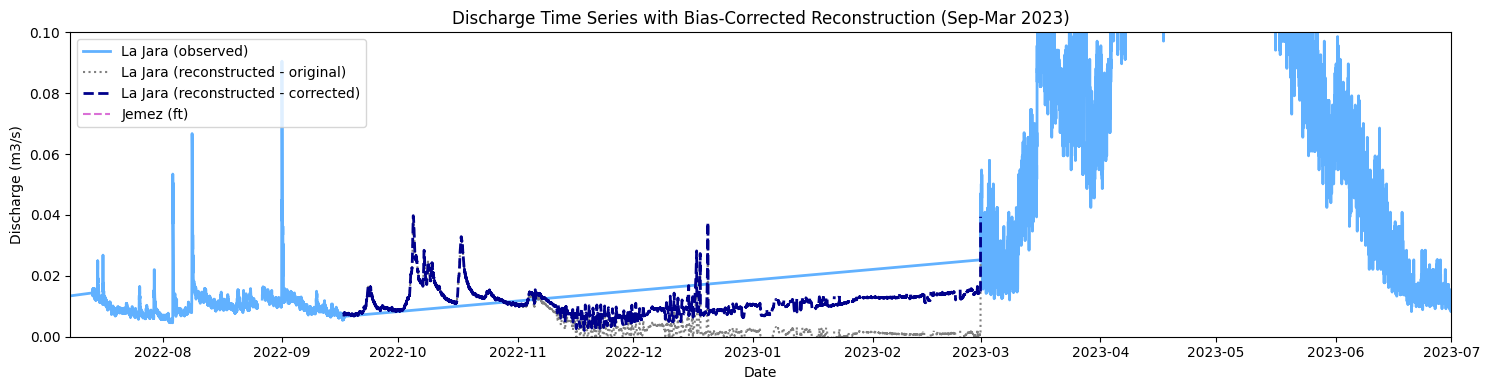

In [18]:
fig, ax = plt.subplots(figsize=(15, 4))

# plot original La Jara data (both years)
ax.plot(lajara_full.index, lajara_full['la_jara'], 
        label='La Jara (observed)', color='dodgerblue', linewidth=2, alpha=0.7)

# plot original reconstructed discharge (without correction)
reconstructed = lajara_sanantonio.loc[gap_mask]
ax.plot(reconstructed.index, reconstructed['la_jara'], 
        label='La Jara (reconstructed - original)', color='gray', linestyle=':', linewidth=1.5, alpha=1)

# plot bias-corrected reconstructed discharge
ax.plot(reconstructed.index, lajara_sanantonio.loc[gap_mask, 'la_jara_adjusted'], 
        label='La Jara (reconstructed - corrected)', color='darkblue', linestyle='--', linewidth=2, alpha=1)

ax.set_ylabel('Discharge (m3/s)')

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.set_title('Discharge Time Series with Bias-Corrected Reconstruction (Sep-Mar 2023)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2022-07-08'), pd.Timestamp('2023-07-01'))
ax.set_ylim(0, 0.1)
plt.tight_layout()
plt.show()

### Smooth Nov-Feb ice noise
This smooths only the likely ice-affected period (Nov-Feb) and keeps all other dates unchanged.

Method:
1. Time interpolation inside the target period
2. Median smoother (robust to spikes)
3. Mean smoother (gentle final smoothing)

In [19]:
# smooth only the likely ice-affected period (Nov-Feb)
ice_start = pd.Timestamp('2022-11-01')
ice_end = pd.Timestamp('2023-03-01 23:59:59')

# choose source series (prefer corrected reconstruction if present)
if 'la_jara_adjusted' in lajara_sanantonio.columns:
    source_col = 'la_jara_adjusted'
else:
    source_col = 'la_jara'

la_jara_smoothed = lajara_sanantonio[source_col].copy()
ice_mask = (lajara_sanantonio.index >= ice_start) & (lajara_sanantonio.index <= ice_end)

# work only inside Nov-Feb window
segment = la_jara_smoothed.loc[ice_mask].copy()
# fill short gaps for stable smoothing
segment_interp = segment.interpolate(method='time', limit_direction='both')

# robust two-stage smoothing:
# 1) median filter removes spikes
# 2) mean filter softens residual jitter
segment_smooth = (
    segment_interp
    .rolling('18h', center=True, min_periods=1).median()
    .rolling('8h', center=True, min_periods=1).mean()
)

# replace only Nov-Feb values
la_jara_smoothed.loc[ice_mask] = segment_smooth
lajara_sanantonio['la_jara_smoothed_ice'] = la_jara_smoothed

print(f"Smoothed period: {ice_start.date()} to {ice_end.date()}")
print(f"Input column: {source_col}")
print("Created column: la_jara_smoothed_ice")

Smoothed period: 2022-11-01 to 2023-03-01
Input column: la_jara_adjusted
Created column: la_jara_smoothed_ice


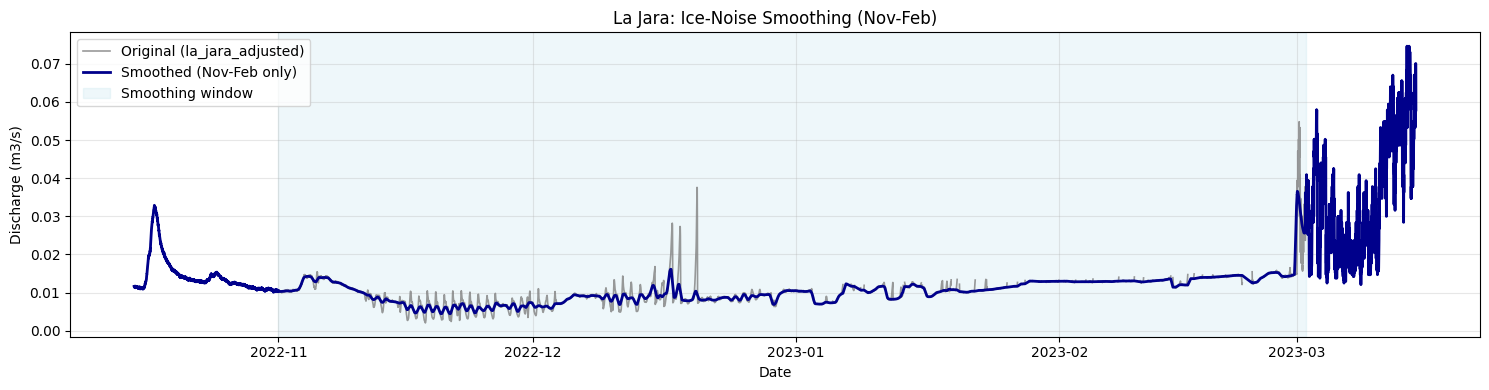

In [20]:
# quick before/after check for Nov-Feb
fig, ax = plt.subplots(figsize=(15, 4))

plot_start = pd.Timestamp('2022-10-15')
plot_end = pd.Timestamp('2023-03-15')
plot_mask = (lajara_sanantonio.index >= plot_start) & (lajara_sanantonio.index <= plot_end)

ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, source_col],
    label=f'Original ({source_col})',
    color='gray',
    linewidth=1.2,
    alpha=0.8
)
ax.plot(
    lajara_sanantonio.index[plot_mask],
    lajara_sanantonio.loc[plot_mask, 'la_jara_smoothed_ice'],
    label='Smoothed (Nov-Feb only)',
    color='darkblue',
    linewidth=2.0
)

ax.axvspan(ice_start, ice_end, color='lightblue', alpha=0.2, label='Smoothing window')
ax.set_title('La Jara: Ice-Noise Smoothing (Nov-Feb)')
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

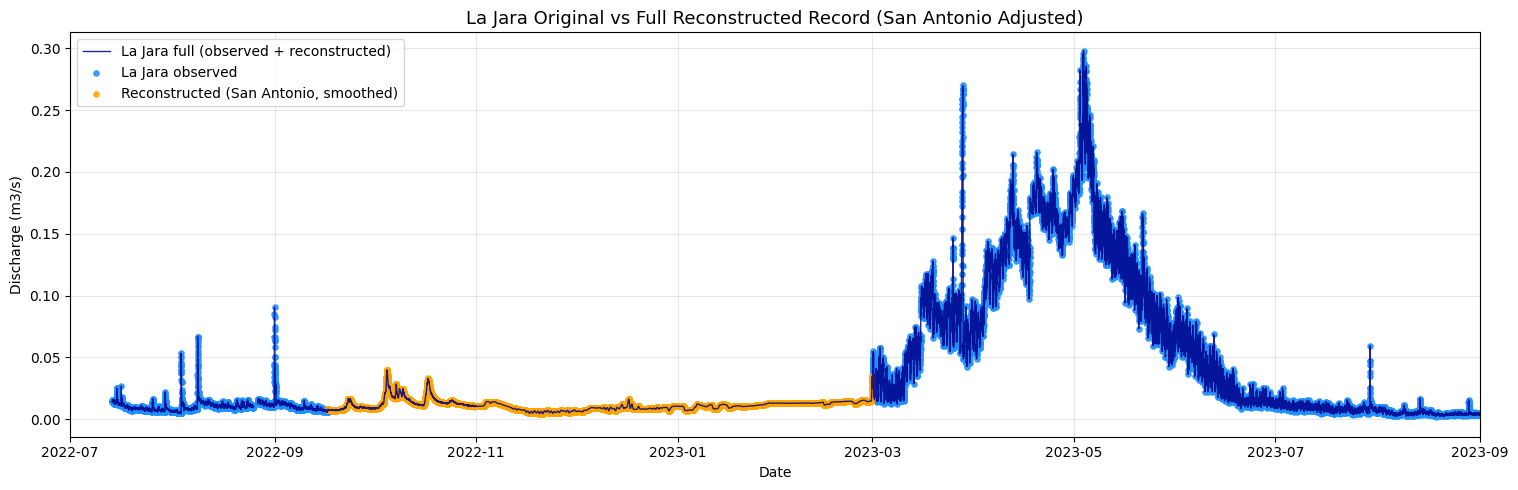

In [21]:
# build final full record using San Antonio bias-corrected + Nov-Feb smoothed reconstruction
obs_2022 = lajara_2022['la_jara'].groupby(level=0).mean()
obs_2023 = lajara_2023['la_jara'].groupby(level=0).mean()
observed_la_jara = pd.concat([obs_2022, obs_2023]).groupby(level=0).mean()

# choose best available San Antonio reconstruction column
if 'la_jara_smoothed_ice' in lajara_sanantonio.columns:
    san_recon_series = lajara_sanantonio['la_jara_smoothed_ice'].groupby(level=0).mean()
elif 'la_jara_adjusted' in lajara_sanantonio.columns:
    san_recon_series = lajara_sanantonio['la_jara_adjusted'].groupby(level=0).mean()
else:
    san_recon_series = lajara_sanantonio['la_jara'].groupby(level=0).mean()

full_index = observed_la_jara.index.union(san_recon_series.index).sort_values()

lajara_full_san = pd.DataFrame(index=full_index)
lajara_full_san['la_jara_observed'] = observed_la_jara
lajara_full_san['la_jara_san_recon'] = san_recon_series

# keep observed where available, fill only gaps with San Antonio reconstruction
lajara_full_san['la_jara_full'] = (
    lajara_full_san['la_jara_observed']
    .combine_first(lajara_full_san['la_jara_san_recon'])
)

fig, ax = plt.subplots(figsize=(15, 5))

# full record after filling gaps
ax.plot(
    lajara_full_san.index,
    lajara_full_san['la_jara_full'],
    color='darkblue',
    linewidth=1,
    alpha=0.85,
    label='La Jara full (observed + reconstructed)'
)

# original observed data only
ax.scatter(
    lajara_full_san.index,
    lajara_full_san['la_jara_observed'],
    color='dodgerblue',
    s=14,
    alpha=0.85,
    label='La Jara observed'
)

# highlight reconstructed points from San Antonio
san_fill_mask = (
    lajara_full_san['la_jara_observed'].isna()
    & lajara_full_san['la_jara_san_recon'].notna()
    & lajara_full_san['la_jara_full'].notna()
)
ax.scatter(
    lajara_full_san.index[san_fill_mask],
    lajara_full_san.loc[san_fill_mask, 'la_jara_full'],
    s=14,
    color='orange',
    alpha=0.85,
    label='Reconstructed (San Antonio, smoothed)'
)

ax.set_title('La Jara Original vs Full Reconstructed Record (San Antonio Adjusted)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.xlim(pd.Timestamp('2022-07-01'), pd.Timestamp('2023-09-01'))
plt.show()

## Plot all together

In [22]:
obs_2022 = lajara_2022['la_jara'].groupby(level=0).mean()
obs_2023 = lajara_2023['la_jara'].groupby(level=0).mean()
observed_la_jara = pd.concat([obs_2022, obs_2023]).groupby(level=0).mean()

# reconstruction series from each source
redondo_recon = reconstructed_hydro['la_jara_hydro'].groupby(level=0).mean()
jemez_recon = lajara_jemez['la_jara'].groupby(level=0).mean()

# choose best available San Antonio reconstruction column
if 'la_jara_smoothed_ice' in lajara_sanantonio.columns:
    san_recon = lajara_sanantonio['la_jara_smoothed_ice'].groupby(level=0).mean()
elif 'la_jara_adjusted' in lajara_sanantonio.columns:
    san_recon = lajara_sanantonio['la_jara_adjusted'].groupby(level=0).mean()
else:
    san_recon = lajara_sanantonio['la_jara'].groupby(level=0).mean()

full_index = (
    observed_la_jara.index
    .union(redondo_recon.index)
    .union(san_recon.index)
    .sort_values()
)

combined = pd.DataFrame(index=full_index)
combined['la_jara_observed'] = observed_la_jara
combined['la_jara_redondo'] = redondo_recon
combined['la_jara_jemez'] = jemez_recon
combined['la_jara_san'] = san_recon


combined['la_jara_full'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
    .combine_first(combined['la_jara_san'])
)

redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

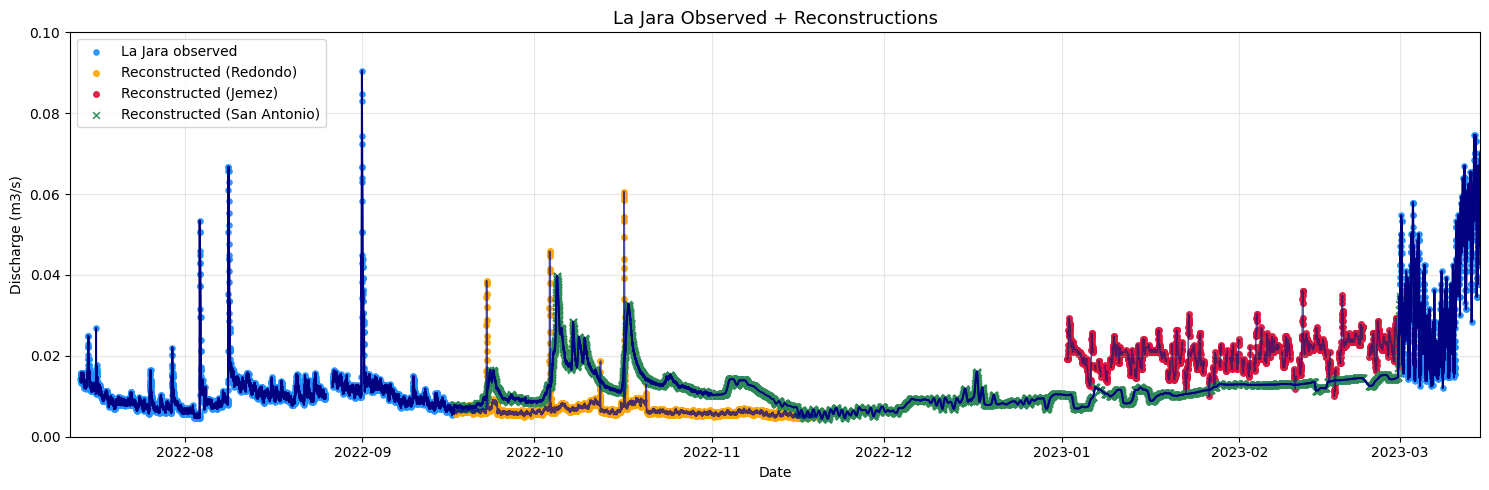

In [23]:
# separate "full" series (observed + one source at a time)
combined['full_redondo'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
)
combined['full_jemez'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_jemez'])
)
combined['full_san'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_san'])
)

# masks (same as before)
redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

fig, ax = plt.subplots(figsize=(15, 5))

# plot each "full" separately (all dark-blue family, different linestyle)
ax.plot(
    combined.index, combined['full_redondo'],
    color='darkblue', linestyle='-', linewidth=1.2, alpha=0.7)
ax.plot(
    combined.index, combined['full_jemez'],
    color='midnightblue', linestyle='-', linewidth=1.2, alpha=0.7)

san_index = observed_la_jara.index.union(san_recon.index).sort_values()
san_only = pd.DataFrame(index=san_index)
san_only['obs'] = observed_la_jara
san_only['san'] = san_recon
san_only['full_san'] = san_only['obs'].combine_first(san_only['san'])

# plot - no breaks
ax.plot(san_only.index, san_only['full_san'], color='navy', linewidth=1.4)
ax.plot(
    combined.index, combined['full_san'],
    color='navy', linestyle='-', linewidth=1.4, alpha=0.8)

# observed points
ax.scatter(
    combined.index, combined['la_jara_observed'],
    color='dodgerblue', s=14, alpha=0.9, label='La Jara observed'
)

# reconstructed points by source
ax.scatter(
    combined.index[redondo_mask], combined.loc[redondo_mask, 'la_jara_redondo'],
    s=16, color='orange', alpha=0.9, label='Reconstructed (Redondo)'
)
ax.scatter(
    combined.index[jemez_mask], combined.loc[jemez_mask, 'la_jara_jemez'],
    s=16, color='crimson', alpha=0.9, label='Reconstructed (Jemez)'
)
ax.scatter(
    combined.index[san_mask], combined.loc[san_mask, 'la_jara_san'],
    s=24, marker='x', linewidths=1.2, color='seagreen', alpha=0.9,
    label='Reconstructed (San Antonio)'
)

ax.set_title('La Jara Observed + Reconstructions', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Discharge (m3/s)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))
plt.ylim(0, 0.1)
plt.tight_layout()
plt.show()

## Plot comparison with precipitation and temperature

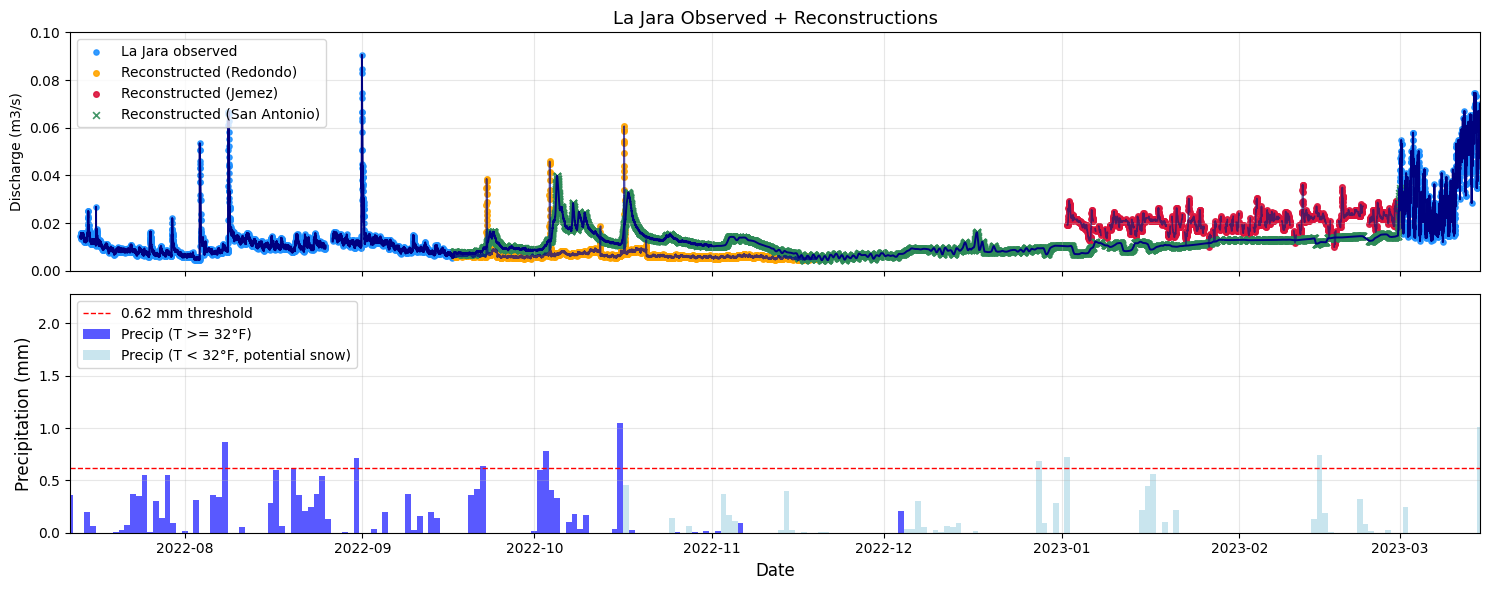

In [24]:
# separate "full" series (observed + one source at a time)
combined['full_redondo'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_redondo'])
)
combined['full_jemez'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_jemez'])
)
combined['full_san'] = (
    combined['la_jara_observed']
    .combine_first(combined['la_jara_san'])
)

# masks (same as before)
redondo_mask = combined['la_jara_observed'].isna() & combined['la_jara_redondo'].notna()
jemez_mask   = combined['la_jara_observed'].isna() & combined['la_jara_jemez'].notna()
san_mask     = combined['la_jara_observed'].isna() & combined['la_jara_san'].notna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
# plot each "full" separately (all dark-blue family, different linestyle)
ax1.plot(
    combined.index, combined['full_redondo'],
    color='darkblue', linestyle='-', linewidth=1.2, alpha=0.7)
ax1.plot(
    combined.index, combined['full_jemez'],
    color='midnightblue', linestyle='-', linewidth=1.2, alpha=0.7)

san_index = observed_la_jara.index.union(san_recon.index).sort_values()
san_only = pd.DataFrame(index=san_index)
san_only['obs'] = observed_la_jara
san_only['san'] = san_recon
san_only['full_san'] = san_only['obs'].combine_first(san_only['san'])

# plot - no breaks
ax1.plot(san_only.index, san_only['full_san'], color='navy', linewidth=1.4)

# observed points
ax1.scatter(
    combined.index, combined['la_jara_observed'],
    color='dodgerblue', s=14, alpha=0.9, label='La Jara observed'
)

# reconstructed points by source
ax1.scatter(
    combined.index[redondo_mask], combined.loc[redondo_mask, 'la_jara_redondo'],
    s=16, color='orange', alpha=0.9, label='Reconstructed (Redondo)'
)
ax1.scatter(
    combined.index[jemez_mask], combined.loc[jemez_mask, 'la_jara_jemez'],
    s=16, color='crimson', alpha=0.9, label='Reconstructed (Jemez)'
)
ax1.scatter(
    combined.index[san_mask], combined.loc[san_mask, 'la_jara_san'],
    s=24, marker='x', linewidths=1.2, color='seagreen', alpha=0.9,
    label='Reconstructed (San Antonio)'
)

ax1.set_title('La Jara Observed + Reconstructions', fontsize=13)
ax1.set_ylabel('Discharge (m3/s)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1.set_ylim(0, 0.1)

# precipitation pannel
# separate precipitation by temperature
precip_warm = precipitation['total_precip'].where(precipitation['avg_temp'] >= 32, 0)
precip_cold = precipitation['total_precip'].where(precipitation['avg_temp'] < 32, 0)

# plot both
ax2.bar(precipitation.index, precip_warm, alpha=0.65, color='blue', width=1, 
        label='Precip (T >= 32°F)')
ax2.bar(precipitation.index, precip_cold, alpha=0.65, color='lightblue', width=1, 
        label='Precip (T < 32°F, potential snow)')
ax2.axhline(y=0.62, color='red', linestyle='--', linewidth=1, label='0.62 mm threshold')
ax2.set_ylabel('Precipitation (mm)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# set x-axis limits for both panels
ax1.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))
ax2.set_xlim(pd.Timestamp('2022-07-12'), pd.Timestamp('2023-03-15'))

plt.tight_layout()
plt.show()

In [40]:
# export all reconstructed discharges 
export_cols = ['la_jara_observed', 'la_jara_redondo', 'la_jara_jemez', 'la_jara_san', 'la_jara_full']
# resample to 15 mins 
lajara = combined['la_jara_full'].copy()
lajara = lajara.resample('15min').interpolate(method='time')
# keep data from 07/14/2022 to 09/18/2023
lajara = lajara.loc['2022-07-14':'2023-09-18']

lajara.to_csv('la_jara_reconstructed_discharge_rsa.csv', index_label='timestamp')

In [41]:
# check the time dif in the index in lajara
time_diffs = lajara.index.to_series().diff().dropna()
print("Time differences between consecutive timestamps in reconstructed La Jara:")
print(time_diffs.value_counts())

Time differences between consecutive timestamps in reconstructed La Jara:
0 days 00:15:00    41471
Name: count, dtype: int64


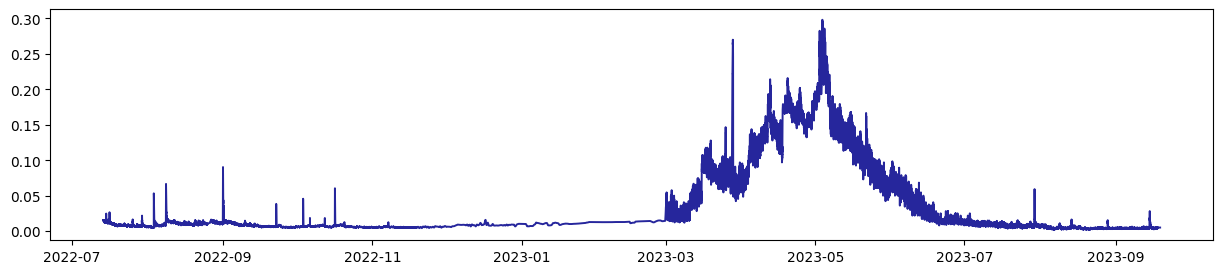

In [42]:
# plot combined la jara full
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(
    lajara,
    color='darkblue', linewidth=1.4, alpha=0.85, label='La Jara full (observed + reconstructed)'
)
plt.show()